<a href="https://colab.research.google.com/github/JJJuniorDev/ML-colab/blob/main/Multiclassification_and_evaluation_metrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Binary Classification with confusion matrix

In [17]:
from sklearn.datasets import make_circles
import pandas as pd
#creiamo 1k
n_samples=1000
X, y= make_circles(n_samples, noise=0.03, random_state=42)

circles=pd.DataFrame({"X0":X[:, 0], "X1":X[:, 1], "label":y})

In [18]:
X_train, y_train=X[:800], y[:800]
X_test, y_test=X[800:], y[800:] #da 800 in poi
X_train.shape, X_test.shape

((800, 2), (200, 2))

In [19]:
import tensorflow as tf
tf.random.set_seed(42)

model=tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.02),
                metrics=["accuracy"])

history1=model.fit(X_train, y_train, epochs=25, verbose=0)

In [20]:
from sklearn.metrics import confusion_matrix
y_preds=model.predict(X_test) #ci esce come valori di probabilità usando sigmoid (es. 9.85e-01)
#confusion matrix li vuole tutti simili quindi rendiamo X_test in 0 e 1 con round

confusion_matrix(y_test,tf.round(y_preds))

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


array([[100,   1],
       [  0,  99]])

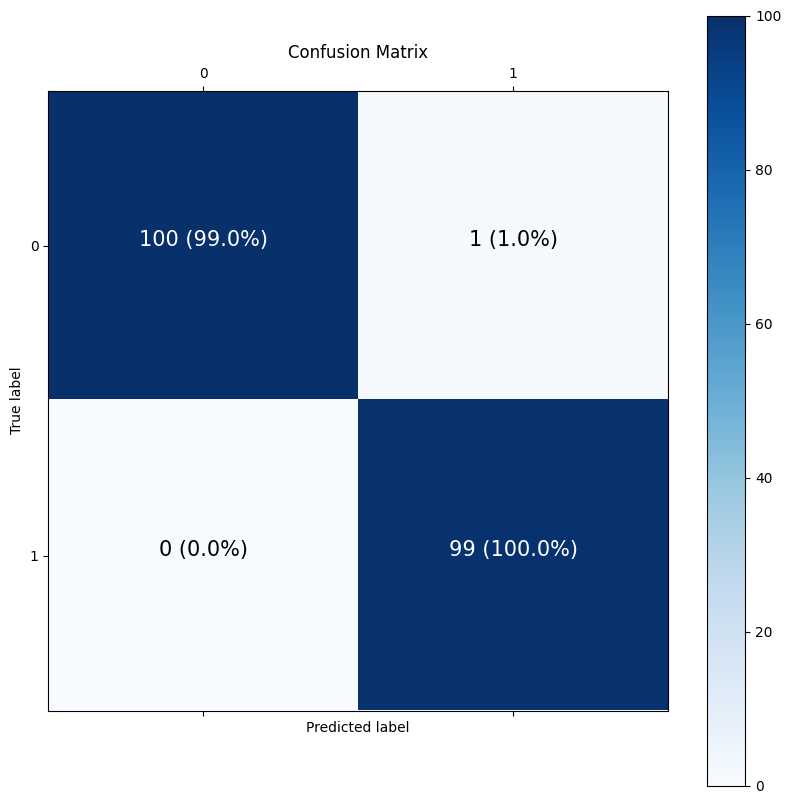

In [21]:
#rendiamo la confusion matrix piu carina
import itertools
import numpy as np
import matplotlib.pyplot as plt

figsize=(10,10)

cm=confusion_matrix(y_test,tf.round(y_preds))
cm_norm= cm.astype("float") / cm.sum(axis=1)[:, np.newaxis] #normalizza la cm
n_classes=cm.shape[0]

fig, ax=plt.subplots(figsize=figsize)
#matrix plot
cax=ax.matshow(cm, cmap=plt.cm.Blues) #plt.cm=color map
fig.colorbar(cax)
#classi
classes= False
if classes:
  labels=classes
else:
  labels= np.arange(cm.shape[0])

#label axes
ax.set(title="Confusion Matrix",
       xlabel="Predicted label",
       ylabel="True label",
       xticks=np.arange(n_classes),
       yticks=np.arange(n_classes),
       xticklabels=labels,
       yticklabels=labels)
#threshold ci da colori diversi dei quadrati in base a quanti valori hanno
#piu scuri o meno
threshold= (cm.max()+cm.min()) /2

#plot text in ogni cella
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
  plt.text(j, i, f"{cm[i,j]} ({cm_norm[i,j]*100:.1f}%)",
           horizontalalignment="center",
           color="white" if cm[i,j] > threshold else "black",
           size=15)

Multiclass Classification

In [22]:
from tensorflow.keras.datasets import fashion_mnist
#dati già splittati in training e test
(train_data, train_labels), (test_data, test_labels)=fashion_mnist.load_data()

In [23]:
#vediamo la forma di un esempio
train_data[0].shape, train_labels[0].shape

((28, 28), ())

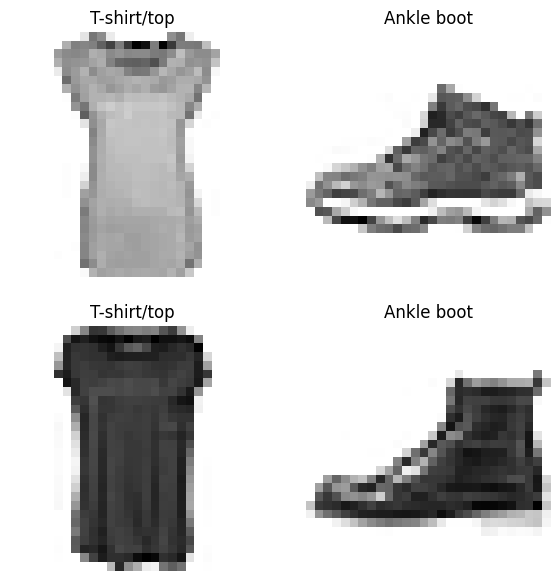

In [24]:
#plottiamo
import random

class_names=["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

plt.figure(figsize=(7,7))
for i in range (4):
  ax=plt.subplot(2,2,i+1)
  rand_index= random.choice(range(len(train_data)))
  plt.imshow(train_data[rand_index], cmap=plt.cm.binary)
  plt.title(class_names[train_labels[rand_index]])
  plt.axis(False)

In [25]:
#architettura multi-class classification
#output activation con softmax invece di sigmoid
#loss function= SparseCategoricalCrossEntropy e non BinaryCrossEntropy
#se le labels sono one-hot encoded uso CategoricalCrossEntropy
#se sono integer uso SparseCategoricalCrossEntropy
tf.random.set_seed(42)

model_1=tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)), #schiaccia tutto in 1 vettore
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

model_1.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

non_norm_history=model_1.fit(train_data, train_labels,
                             epochs=10, validation_data=(test_data, test_labels))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.0965 - loss: 2.6476 - val_accuracy: 0.1000 - val_loss: 2.3028
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.0990 - loss: 2.3027 - val_accuracy: 0.1000 - val_loss: 2.3028
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.0986 - loss: 2.3026 - val_accuracy: 0.1000 - val_loss: 2.3028
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.0986 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3028
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.0985 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3028
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.0985 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3028
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.0985 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3028
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.0985 - loss: 2.3028

In [26]:
#vediamo min e massimo valori sono 0 e 255
train_data.min(), train_data.max()

(np.uint8(0), np.uint8(255))

In [27]:
#neural networks preferiscono dati normalizzati e scalati tra 0 e 1
#possiamo dividere per il max
train_data_norm=train_data/255.0
test_data_norm=test_data/255.0
train_data_norm.min(), train_data_norm.max()

(np.float64(0.0), np.float64(1.0))

In [28]:
tf.random.set_seed(42)
model_normalized_data=tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)), #schiaccia tutto in 1 vettore
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

model_normalized_data.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

norm_history=model_normalized_data.fit(train_data_norm, train_labels,
                             epochs=10, validation_data=(test_data_norm, test_labels))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.3948 - loss: 1.5155 - val_accuracy: 0.6305 - val_loss: 0.9691
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6487 - loss: 0.9122 - val_accuracy: 0.6723 - val_loss: 0.8222
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6982 - loss: 0.7880 - val_accuracy: 0.7377 - val_loss: 0.7359
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7623 - loss: 0.6879 - val_accuracy: 0.7685 - val_loss: 0.6709
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7788 - loss: 0.6371 - val_accuracy: 0.7717 - val_loss: 0.6512
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7857 - loss: 0.6162 - val_accuracy: 0.7748 - val_loss: 0.6357
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.7897 - loss: 0.6009 - val_accuracy: 0.7783 - val_loss: 0.6270
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7930 - loss: 0.5902 - 

<Axes: title={'center': 'Normalized data'}>

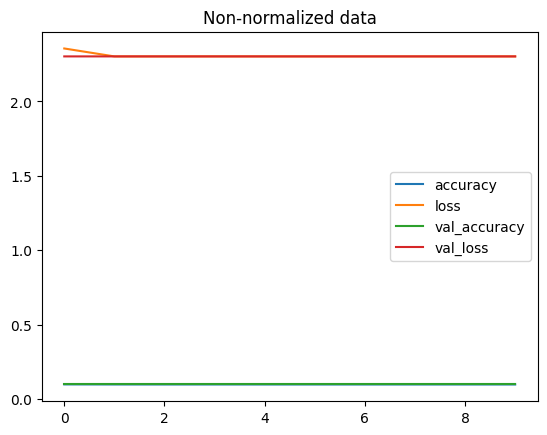

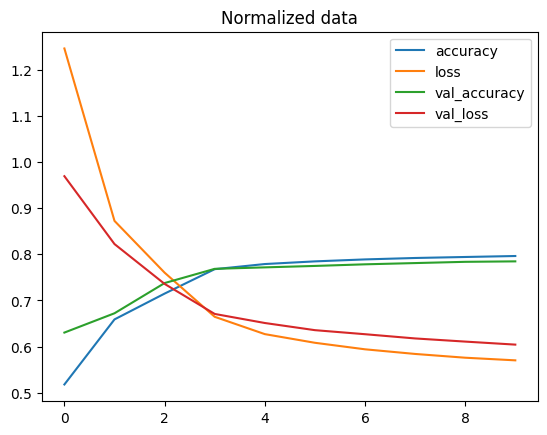

In [29]:
pd.DataFrame(non_norm_history.history).plot(title="Non-normalized data")
pd.DataFrame(norm_history.history).plot(title="Normalized data")

In [30]:
tf.random.set_seed(42)
model_normalized_data_with_lr=tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)), #schiaccia tutto in 1 vettore
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

model_normalized_data_with_lr.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

lr_scheduler=tf.keras.callbacks.LearningRateScheduler(lambda epoch: 1e-3 * 10 **(epoch/20))
find_lr_history=model_normalized_data_with_lr.fit(train_data_norm, train_labels,
                             epochs=40, validation_data=(test_data_norm, test_labels),
                                                  callbacks=[lr_scheduler])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.5150 - loss: 1.2807 - val_accuracy: 0.7326 - val_loss: 0.7276 - learning_rate: 0.0010
Epoch 2/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7524 - loss: 0.6858 - val_accuracy: 0.7734 - val_loss: 0.6347 - learning_rate: 0.0011
Epoch 3/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7841 - loss: 0.6071 - val_accuracy: 0.7977 - val_loss: 0.5916 - learning_rate: 0.0013
Epoch 4/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8036 - loss: 0.5670 - val_accuracy: 0.8062 - val_loss: 0.5710 - learning_rate: 0.0014
Epoch 5/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8106 - loss: 0.5474 - val_accuracy: 0.8099 - val_loss: 0.5599 - learning_rate: 0.0016
Epoch 6/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8148 - loss: 0.5362 - val_accuracy: 0.8117 - val_loss: 0.5522 - learning_rate: 0.0018
Epoch 7/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8181 - 

Text(0.5, 1.0, 'Finding the ideal learning rate')

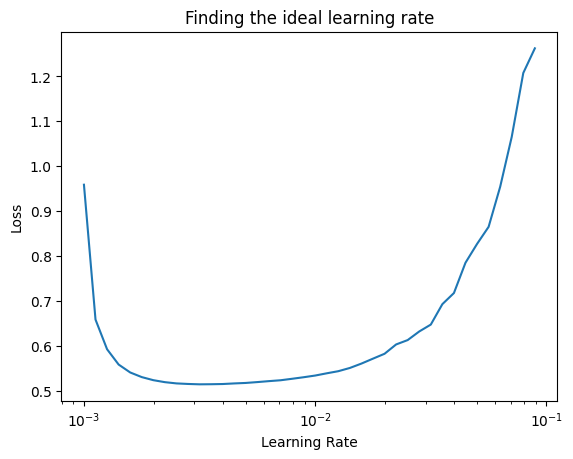

In [31]:
#plot the learning rate decay curve
lrs= 1e-3 * (10 **(tf.range(40)/20))
plt.semilogx(lrs, find_lr_history.history["loss"])
plt.xlabel("Learning Rate")
plt.ylabel("Loss")
plt.title("Finding the ideal learning rate")